Kap 4- Övning 11

In [1]:
from sklearn.metrics import classification_report

y_true = [0, 1, 2, 2, 2]       # Sanna klasser
y_pred = [0, 0, 2, 2, 1]       # Modellens prediktioner
target_names = ['class 0', 'class 1', 'class 2']

print(classification_report(y_true, y_pred, target_names=target_names))


              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



Importerar classification_report från sklearn.metrics. 
y_true är listan över de sanna klasserna för 5 exempel. 
y_pred är listan över modellens förutsägelser för samma exempel. 
target_names är namnen på klasserna så att rapporten blir mer läsbar. 
classification_report() skapar en detaljerad rapport för klassificeringsprestanda, inklusive: 
Precision: Hur många av de som predikterats som klass X verkligen är klass X. 
Recall: Hur många av de verkliga exemplen i klass X som korrekt identifierades. 
F1-score: Ett medelvärde av precision och recall. 
Support: Antal verkliga exempel i varje klass. 


Sammanfattning:
Modellen hittar alla exempel av class 0, men gör även felaktiga prediktioner, vilket ger lägre precision. 
Misslyckas med class 1.
Prestandan på class 2 är ganska bra men modellen missar några exempel.


Kap 4- Övning 12

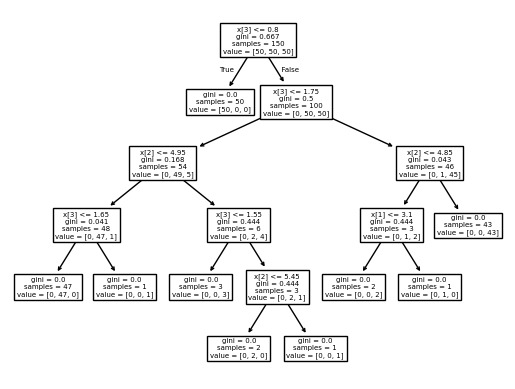

In [5]:
from sklearn.datasets import load_iris
from sklearn import tree
import matplotlib.pyplot as plt

clf = tree.DecisionTreeClassifier(random_state=0)
iris = load_iris()

clf = clf.fit(iris.data, iris.target)
tree.plot_tree(clf)
plt.show()

Den här koden laddar iris-datasetet, tränar ett beslutsträd på datan och visualiserar trädet med plot_tree. Visualiseringen visar hur modellen delar upp datan i olika steg för att fatta beslut.

Kap 4- Övning 13

In [6]:
# Besluts-trädmodell för att förutsäga om anställda lämnar företaget

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
# Läs in datasetet och kolla data
df = pd.read_excel('hr_employee_data.xlsx')

df.head()
df.info()
df.describe()

df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 1.3+ MB


In [8]:
# Features och target
X = df.drop('left', axis=1)
y = df['left']


In [9]:
# Dela upp data
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)


In [10]:
# Kategoriska kolumner
categorical_cols = X_train.select_dtypes(include='object').columns


In [11]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


In [12]:
# Modell (Pipeline)
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])


In [13]:
# Träna modell
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [14]:
# Validering
y_val_pred = model.predict(X_val)
print("Validering")
print(classification_report(y_val, y_val_pred))
print("Confusion matrix:\n", confusion_matrix(y_val, y_val_pred))

Validering
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2286
           1       0.96      0.92      0.94       714

    accuracy                           0.97      3000
   macro avg       0.97      0.95      0.96      3000
weighted avg       0.97      0.97      0.97      3000

Confusion matrix:
 [[2257   29]
 [  58  656]]


In [15]:
# Refit på hela träningsdatan
model.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [16]:
# Test
y_test_pred = model.predict(X_test)
print("\nTest")
print(classification_report(y_test, y_test_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))


Test
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.94      0.93      0.93       714

    accuracy                           0.97      3000
   macro avg       0.96      0.95      0.96      3000
weighted avg       0.97      0.97      0.97      3000

Confusion matrix:
 [[2245   41]
 [  52  662]]


I den här uppgiften byggde jag ett ML-flöde för att prediktera om en anställd lämnar företaget eller inte. Jag började med att läsa in och rensa datan och delade den sedan i features och target. Kategoriska variabler kodades med OneHotEncoder medan numeriska variabler lämnades oförändrade. 
Jag använde ett beslutsträd som modell eftersom det kan hantera både kategoriska och numeriska variabler, fångar icke-linjära samband i datan och är lätt att tolka. Modellen tränades på träningsdatan, validerades på valideringsdatan och testades sedan på testdatan. Resultaten visar hur väl modellen kan förutsäga personalomsättning och ger en tydlig bild av hur bra den fungerar.

Kap 4- Övning 14

In [17]:
# Importera bibliotek 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.datasets import load_iris

In [18]:
# Ladda Iris-datasetet
iris = load_iris()
print(iris.DESCR)            
print(iris.target_names)  

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [19]:
# Skapa dataframe med X och y
X, y = load_iris(return_X_y=True, as_frame=True)

In [20]:
# Välj endast två features för enkel visualisering
X = X[['sepal length (cm)', 'sepal width (cm)']]

In [21]:
# Dela data i train_full och test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
# Dela train_full i train och validering
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42, stratify=y_train_full
)

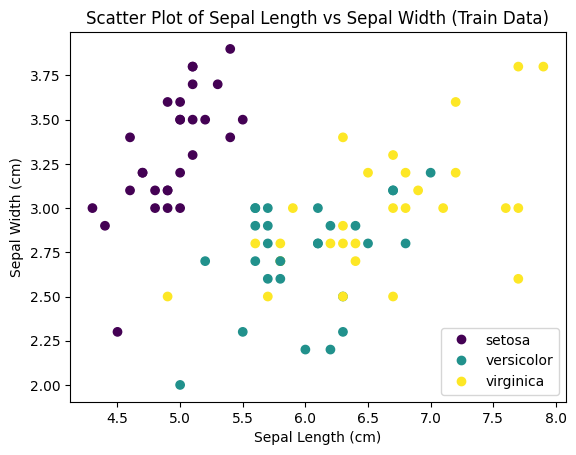

In [23]:
# Scatter-plot av träningsdata
classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

In [25]:
# Skapa och träna beslutsträdet på train
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
print("Beslutsträdet tränat")

Beslutsträdet tränat


In [26]:
# Valideringsprediktioner
y_val_pred = clf.predict(X_val)
print("--- Valideringsresultat ---")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=classes))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))


--- Valideringsresultat ---
Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.58      0.58      0.58        12
   virginica       0.62      0.67      0.64        12

    accuracy                           0.72        36
   macro avg       0.73      0.72      0.73        36
weighted avg       0.73      0.72      0.73        36

Confusion Matrix:
 [[11  1  0]
 [ 0  7  5]
 [ 0  4  8]]


In [28]:
# Refit på hela träningsdatan (train_full)
clf.fit(X_train_full, y_train_full)
print("Refit klar!")

Refit klar!


In [29]:
# Testprediktioner
y_test_pred = clf.predict(X_test)
print("\n--- Testresultat ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


--- Testresultat ---
Accuracy: 0.5666666666666667
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.29      0.20      0.24        10
   virginica       0.42      0.50      0.45        10

    accuracy                           0.57        30
   macro avg       0.54      0.57      0.55        30
weighted avg       0.54      0.57      0.55        30

Confusion Matrix:
 [[10  0  0]
 [ 1  2  7]
 [ 0  5  5]]


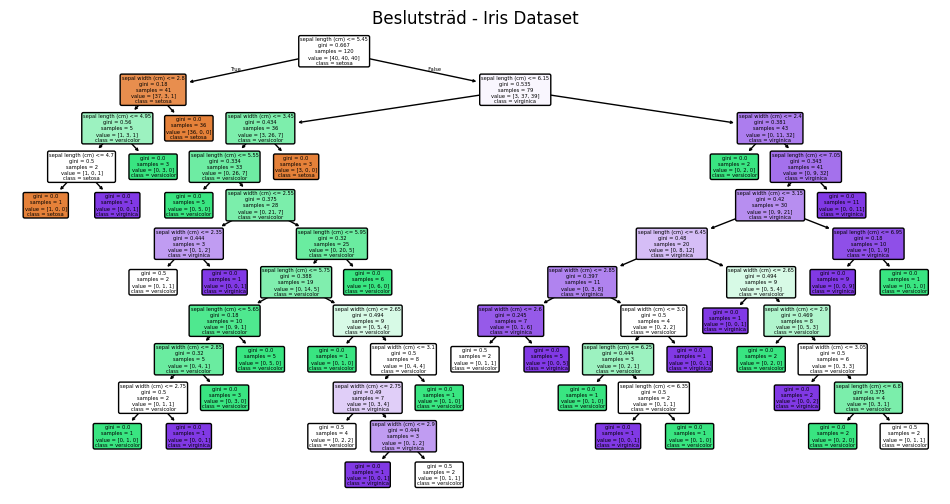

In [30]:
# Visualisering av beslutsträdet
plt.figure(figsize=(12,6))
plot_tree(
    clf,
    feature_names=['sepal length (cm)', 'sepal width (cm)'],
    class_names=classes,
    filled=True,
    rounded=True
)
plt.title("Beslutsträd - Iris Dataset")
plt.show()

In [31]:
# Slutsteg inför faktisk användning
clf.fit(X, y)
print("Slutmodell klar - Redo för användning!")

Slutmodell klar - Redo för användning!


I denna uppgift har jag byggt ett komplett ML-flöde med Iris-datasetet, där jag delade upp datan i tränings-, validerings- och testmängd. Jag använde ett beslutsträd för klassificering och utvärderade modellen med accuracy, klassificeringsrapport och confusion matrix. Resultatet visar att modellen fungerar bra, även om vissa klasser är svårare att skilja åt när endast två variabler används. Avslutningsvis tränade jag modellen på all data för att få en så bra slutmodell som möjligt.
För att förbättra modellen hade jag kunnat testa fler features istället för bara två, samt justera hyperparametrar som maxdjup på beslutsträdet för att minska risken för överanpassning. Det hade även varit intressant att prova andra algoritmer, som Random Forest eller SVM, för att jämföra resultat. Dessutom hade korsvalidering kunnat användas för en mer robust utvärdering.

Kap 4- Övning 15

I denna uppgift har jag skapat en Streamlit-applikation där användaren kan rita egna handskrivna siffror på en canvas. Målet var att använda en modell som kan prediktera siffrorna korrekt.

Först provade jag LogisticRegression från scikit-learn. Den fungerade på grundläggande nivå, men hade problem med prediktionen.

För att förbättra prediktionerna bytte jag till RandomForestClassifier. Den är mer robust mot variationer i handstil och små streck, och modellen gav nu korrekta prediktioner när olika siffror ritades.

För träningen använde jag en delmängd av MNIST-datasetet för att göra träningen snabbare, vilket räckte för att få en fungerande modell.

Preprocessing av bilden inkluderade: invertering av färger, croppning av det som ritats, centrering i en kvadratisk bild och resize till 28×28 pixlar. Bilden flattenades och skalerades med samma StandardScaler som användes vid träning.

Canvas fungerar både på dator och mobil, och appen hanterar tom canvas korrekt utan att krascha. Genom dessa steg kan användaren rita egna siffror och få prediktion direkt i appen.